In [ ]:
import json
import numpy as np
from pathlib import Path
from tqdm import tqdm

from bird_cv.segmentation.segment import get_camera_sam_config, segment
from bird_cv.segmentation.visualize import vizualize_segmentations, annotate_and_copy

SEGMENTATION_CONFIG_PATH = Path("/Users/sdougherty/Documents/code/data/segmentation_test")
VIDEO_BASE_PATH = Path("/Users/sdougherty/Documents/code/data/2021_bunting_clips")
MODEL_CHECKPOINT_PATH = Path("/Users/sdougherty/Documents/code/sam2/checkpoints")

# I won't take more than 10 frames per camera
# I should devise a method to smooth out the noise masks

# butt in 0137 of L17

To assemble a test set for segmentation, we will manually label ~ 100 segments using the interactive output from the SAM2 model.

For each camera, I will choose 2 frames at random to label.

In [ ]:
import cv2
import os
import random
from pathlib import Path

def extract_random_frames(video_path, n_frames, output_dir, seed=None):
    """
    Extract N random frames from a video and save them as JPG files.

    Args:
        video_path (str or Path): Path to input .mp4 video
        n_frames (int): Number of random frames to extract
        output_dir (str or Path): Directory to save JPG images
        prefix (str): Filename prefix (default: "frame")
        seed (int, optional): Random seed for reproducibility
    """
    if seed is not None:
        random.seed(seed)

    video_path = str(video_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if n_frames > total_frames:
        raise ValueError(f"Requested {n_frames} frames, but video only has {total_frames} frames.")

    # Randomly select unique frame indices
    frame_indices = sorted(random.sample(range(total_frames), n_frames))

    current_frame = 0
    target_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if target_idx >= len(frame_indices):
            break

        if current_frame == frame_indices[target_idx]:
            filename = output_dir / f"{current_frame:06d}.jpg"
            cv2.imwrite(str(filename), frame)
            target_idx += 1

        current_frame += 1

    cap.release()

    if target_idx < len(frame_indices):
        missing = frame_indices[target_idx:]
        print(f"Warning: Could not extract frames: {missing}")

In [ ]:
video_exts = {
    ".mp4", ".avi", ".mkv", ".mov", ".wmv",
    ".flv", ".webm", ".m4v", ".ts", ".mts"
}

camera_ids = list(VIDEO_BASE_PATH.iterdir())
for camera in tqdm(camera_ids):
    if camera.stem != ".DS_Store":
        videos = list(camera.iterdir())
        for video in videos:
            if video.suffix.lower() in video_exts:
                extract_random_frames(
                    video_path=VIDEO_BASE_PATH / camera.stem / video.name,
                    n_frames=2,
                    output_dir=SEGMENTATION_CONFIG_PATH / "frames" / camera.stem / video.stem
                )

## H7,I22

In [ ]:
guess_prompts = {
    "H7": {
        "points": np.array(
            [
                [500, 600], [750, 400], [400, 850], [300, 500],
                [260,850], [500,400], [700,600]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,0,1,1], np.int32)
    }, 
    "I22": {
        "points": np.array(
            [
                [1250, 750], [1250, 350], [1500,500],
                [1650, 800], [1500,300]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,0,1], np.int32)
    }, 
}

camera_id = "H7,I22"
video_id = "37"
ann_frame_idx = 1
get_camera_sam_config(
    model_checkpoint_path=MODEL_CHECKPOINT_PATH,
    video_base_path=SEGMENTATION_CONFIG_PATH  / "frames",
    camera_id=camera_id,
    video_id=video_id,
    guess_prompts=guess_prompts,
    ann_frame_idx=ann_frame_idx,
    winner=False,
    output_config_path=None,
    return_video_segments=True,
    output_segment_path=SEGMENTATION_CONFIG_PATH / "labels" / camera_id / f"{video_id}_{ann_frame_idx}.json"
)

## H8,I29,I25,L12

In [ ]:
guess_prompts = {
    "H8": {
        "points": np.array(
            [
                [500, 50], [500, 300], [750, 50], [750, 400],
                [500,400],
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,0], np.int32)
    }, 
    "I29": {
        "points": np.array(
            [
                [1050, 50], [1400, 200], [1000,300],
                [1500, 420], [1400,300]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,0,1], np.int32)
    }, 
    "I25": {
        "points": np.array(
            [
                [400, 600], [800, 700], [500,900],
                [500, 1000], [850,900]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,0,1], np.int32)
    }, 
    "L12": {
        "points": np.array(
            [
                [1150, 600], [1500, 600], [1100,900],
                [1500, 960], [1400,900]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,0,1], np.int32)
    }, 
}

camera_id = "H8,I29,I25,L12"
video_id = "LocalRecord7C78B275FF2B_album_local_cache 12"
ann_frame_idx = 0
get_camera_sam_config(
    model_checkpoint_path=MODEL_CHECKPOINT_PATH,
    video_base_path=SEGMENTATION_CONFIG_PATH  / "frames",
    camera_id=camera_id,
    video_id=video_id,
    guess_prompts=guess_prompts,
    ann_frame_idx=ann_frame_idx,
    winner=False,
    output_config_path=None,
    return_video_segments=True,
    output_segment_path=SEGMENTATION_CONFIG_PATH / "labels" / camera_id / f"{video_id}_{ann_frame_idx}.json"
)

## H9

In [ ]:
guess_prompts = {
    "H9": {
        "points": np.array(
            [
                [100, 100], [1200, 100], [100, 600], [1200, 600], [110,450], [490,100], [300,100],# [450,50],
                [200,700], # [0,400], [20,100]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,1,1,1,0], np.int32)
    }, 
}

camera_id = "H9"
video_id = "IMG_0247"
ann_frame_idx = 1
get_camera_sam_config(
    model_checkpoint_path=MODEL_CHECKPOINT_PATH,
    video_base_path=SEGMENTATION_CONFIG_PATH  / "frames",
    camera_id=camera_id,
    video_id=video_id,
    guess_prompts=guess_prompts,
    ann_frame_idx=ann_frame_idx,
    winner=False,
    output_config_path=None,
    return_video_segments=True,
    output_segment_path=SEGMENTATION_CONFIG_PATH / "labels" / camera_id / f"{video_id}_{ann_frame_idx}.json"
)

## H14,I19,L24,I30

In [ ]:
guess_prompts = {
    "H14": {
        "points": np.array(
            [
                [299, 40], [949, 26], [971, 266], [306, 326], [462, 26], [258, 183],
                [697, 329], [212, 189]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,1,1,0,0], np.int32)
    }, 
    "I19": {
        "points": np.array(
            [
                [1121, 269], [1751, 305], [1706, 45], [1108, 32], [1717, 142], [1557, 69], [1369, 63],
                [1406, 327], [1045, 143], [1788, 140]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,1,1,1,0,0,0], np.int32)
    }, 
    "L24": {
        "points": np.array(
            [
                [104, 512], [807, 477], [774, 1035], [176, 957], [707, 767], [474, 673],
                [925, 820], 
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,1,1,0], np.int32)
    }, 
    "I30": {
        "points": np.array(
            [
                [994, 431], [1783, 458], [1735, 945], [1041, 1041], [1152, 624], [1496, 858], [1441, 486],
                [924, 828],
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,1,1,1,0], np.int32)
    }, 
}

camera_id = "H14,I19,L24,I30"
video_id = "20" # 21 frames got deleted...
ann_frame_idx = 1

# Interactive annotation
video_path = SEGMENTATION_CONFIG_PATH  / "frames"
files = list((video_path / camera_id / video_id).iterdir())
annotate_and_copy(files[ann_frame_idx])

get_camera_sam_config(
    model_checkpoint_path=MODEL_CHECKPOINT_PATH,
    video_base_path=SEGMENTATION_CONFIG_PATH  / "frames",
    camera_id=camera_id,
    video_id=video_id,
    guess_prompts=guess_prompts,
    ann_frame_idx=ann_frame_idx,
    winner=False,
    output_config_path=None,
    return_video_segments=True,
    output_segment_path=SEGMENTATION_CONFIG_PATH / "labels" / camera_id / f"{video_id}_{ann_frame_idx}.json"
)

## H15,L16

In [ ]:
guess_prompts = {
    "H15": {
        "points": np.array(
            [
                [55, 294], [661, 181], [705, 811], [214, 852], [238, 310], [420, 658], [400, 134], [42, 525], [497, 895], [725, 449]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,1,1,0,0,0,0], np.int32)
    }, 
    "L16": {
        "points": np.array(
            [
                [762, 163], [1382, 168], [1319, 685], [826, 777], [891, 544], [966, 343], [960, 63], [725, 439], [1083, 803], [1433, 348],
                [832, 256]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,1,1,0,0,0,0,1], np.int32)
    }, 
}

camera_id = "H15,L16"
video_id = "56"
ann_frame_idx = 0

# Interactive annotation
video_path = SEGMENTATION_CONFIG_PATH  / "frames"
files = list((video_path / camera_id / video_id).iterdir())
annotate_and_copy(files[ann_frame_idx])

get_camera_sam_config(
    model_checkpoint_path=MODEL_CHECKPOINT_PATH,
    video_base_path=SEGMENTATION_CONFIG_PATH  / "frames",
    camera_id=camera_id,
    video_id=video_id,
    guess_prompts=guess_prompts,
    ann_frame_idx=ann_frame_idx,
    winner=False,
    output_config_path=None,
    return_video_segments=True,
    output_segment_path=SEGMENTATION_CONFIG_PATH / "labels" / camera_id / f"{video_id}_{ann_frame_idx}.json"
)

## H19,L24

In [ ]:
guess_prompts = {
    "H19": {
        "points": np.array(
            [
                [417, 281], [736, 290], [416, 695], [815, 682], [796, 1051], [470, 1015], [771, 221], [486, 396], [362, 729], [865, 920],
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,1,1,0,0,0,0], np.int32)
    }, 
    "L24": {
        "points": np.array(
            [
                [1055, 239], [1546, 279], [1576, 480], [1088, 503], [1212, 320], [1437, 257], [1502, 485], [1503, 207], [1031, 404], [1236, 536]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,1,1,1,0,0,0], np.int32)
    }, 
}

camera_id = "H19,L24"
video_id = "50"
ann_frame_idx = 0

# Interactive annotation
video_path = SEGMENTATION_CONFIG_PATH  / "frames"
files = list((video_path / camera_id / video_id).iterdir())
annotate_and_copy(files[ann_frame_idx])

get_camera_sam_config(
    model_checkpoint_path=MODEL_CHECKPOINT_PATH,
    video_base_path=SEGMENTATION_CONFIG_PATH  / "frames",
    camera_id=camera_id,
    video_id=video_id,
    guess_prompts=guess_prompts,
    ann_frame_idx=ann_frame_idx,
    winner=False,
    output_config_path=None,
    return_video_segments=True,
    output_segment_path=SEGMENTATION_CONFIG_PATH / "labels" / camera_id / f"{video_id}_{ann_frame_idx}.json"
)

## I20,I38

In [ ]:
guess_prompts = {
    "I20": {
        "points": np.array(
            [
                [508, 214], [838, 169], [904, 567], [499, 514], [718, 218], [985, 378]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,1,0], np.int32)
    }, 
    "I38": {
        "points": np.array(
            [
                [1093, 206], [1422, 246], [1452, 615], [1078, 550], [1040, 422]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1, 0], np.int32)
    }, 
}

camera_id = "I20,I38"
video_id = "58"
ann_frame_idx = 0

# Interactive annotation
video_path = SEGMENTATION_CONFIG_PATH  / "frames"
files = list((video_path / camera_id / video_id).iterdir())
annotate_and_copy(files[ann_frame_idx])

get_camera_sam_config(
    model_checkpoint_path=MODEL_CHECKPOINT_PATH,
    video_base_path=SEGMENTATION_CONFIG_PATH  / "frames",
    camera_id=camera_id,
    video_id=video_id,
    guess_prompts=guess_prompts,
    ann_frame_idx=ann_frame_idx,
    winner=False,
    output_config_path=None,
    return_video_segments=True,
    output_segment_path=SEGMENTATION_CONFIG_PATH / "labels" / camera_id / f"{video_id}_{ann_frame_idx}.json"
)

## I27,I34,H12,H16,L21

In [ ]:
guess_prompts = {
    "I27": {
        "points": np.array(
            [
                [31, 89], [100, 64], [33, 226], [89, 241], [119, 147]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,0], np.int32)
    }, 
    "I34": {
        "points": np.array(
            [
                [179, 156], [205, 18], [281, 38], [273, 152], [190, 110]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,0], np.int32)
    }, 
    "H12": {
        "points": np.array(
            [
                [67, 348], [142, 314], [108, 466], [183, 468], [186, 395]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,0], np.int32)
    }, 
    "H16": {
        "points": np.array(
            [
                [183, 273], [336, 227], [360, 458], [236, 466], [298, 395], [369, 335]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,1,0], np.int32)
    }, 
    "L21": {
        "points": np.array(
            [
                [426, 236], [529, 219], [534, 313], [424, 357], [400, 311], [470, 209], [543, 261], [483, 356]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,0,0,0,0], np.int32)
    }, 
}

camera_id = "I27,I34,H12,H16,L21"
video_id = "22.59.00-23.07.00[R][0@0][0]"
ann_frame_idx = 1

# Interactive annotation
video_path = SEGMENTATION_CONFIG_PATH  / "frames"
files = list((video_path / camera_id / video_id).iterdir())
annotate_and_copy(files[ann_frame_idx])

get_camera_sam_config(
    model_checkpoint_path=MODEL_CHECKPOINT_PATH,
    video_base_path=SEGMENTATION_CONFIG_PATH  / "frames",
    camera_id=camera_id,
    video_id=video_id,
    guess_prompts=guess_prompts,
    ann_frame_idx=ann_frame_idx,
    winner=False,
    output_config_path=None,
    return_video_segments=True,
    output_segment_path=SEGMENTATION_CONFIG_PATH / "labels" / camera_id / f"{video_id}_{ann_frame_idx}.json"
)

## I32,I18,H18,L14,I39

Copied to clipboard: []


frame loading (JPEG): 100%|██████████| 2/2 [00:00<00:00, 90.54it/s]
/Users/sdougherty/Documents/code/sam2/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/Users/sdougherty/Documents/code/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


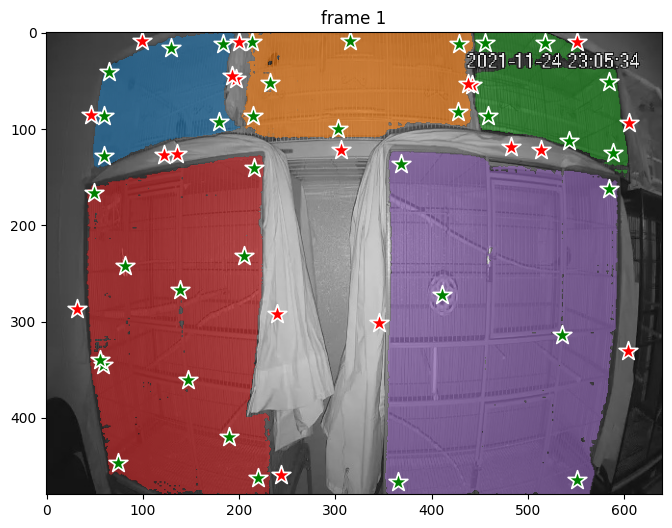

In [263]:
guess_prompts = {
    "I32": {
        "points": np.array(
            [
                [65, 41], [183, 12], [179, 93], [60, 128], [129, 16], [60, 87], [46, 85], [99, 9], [197, 48], [122, 127]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,1,1,0,0,0,0], np.int32)
    }, 
    "I18": {
        "points": np.array(
            [
                [213, 10], [315, 9], [428, 12], [427, 82], [303, 100], [214, 87], [193, 45], [306, 122], [442, 54],
                [232, 52], [200, 10]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,1,1,0,0,0,1,0], np.int32)
    }, 
    "H18": {
        "points": np.array(
            [
                [459, 87], [456, 11], [584, 51], [588, 125], [543, 112], [518, 11], [438, 53], [551, 10], [605, 94], [514, 122]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,1,1,0,0,0,0], np.int32)
    }, 
    "L14": {
        "points": np.array(
            [
                [49, 166], [215, 140], [220, 463], [74, 447], [81, 242], [147, 361], [136, 126], [32, 287], [239, 292], [244, 459],
                [139, 267], [59, 345], [190, 420], [56, 340], [205, 232]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,1,1,0,0,0,0,1,1,1,1,1], np.int32)
    }, 
    "I39": {
        "points": np.array(
            [
                [368, 136], [584, 162], [551, 465], [365, 467], [411, 272], [535, 314], [482, 119], [345, 302], [604, 331]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,1,1,0,0,0], np.int32)
    }, 
}

camera_id = "I32,I18,H18,L14,I39"
video_id = "23.03.00-23.11.00[R][0@0][0]"
ann_frame_idx = 1

# Interactive annotation
video_path = SEGMENTATION_CONFIG_PATH  / "frames"
files = list((video_path / camera_id / video_id).iterdir())
annotate_and_copy(files[ann_frame_idx])

get_camera_sam_config(
    model_checkpoint_path=MODEL_CHECKPOINT_PATH,
    video_base_path=SEGMENTATION_CONFIG_PATH  / "frames",
    camera_id=camera_id,
    video_id=video_id,
    guess_prompts=guess_prompts,
    ann_frame_idx=ann_frame_idx,
    winner=False,
    output_config_path=None,
    return_video_segments=True,
    output_segment_path=SEGMENTATION_CONFIG_PATH / "labels" / camera_id / f"{video_id}_{ann_frame_idx}.json"
)

## I33

Copied to clipboard: []


frame loading (JPEG): 100%|██████████| 2/2 [00:00<00:00, 74.81it/s]
/Users/sdougherty/Documents/code/sam2/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/Users/sdougherty/Documents/code/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


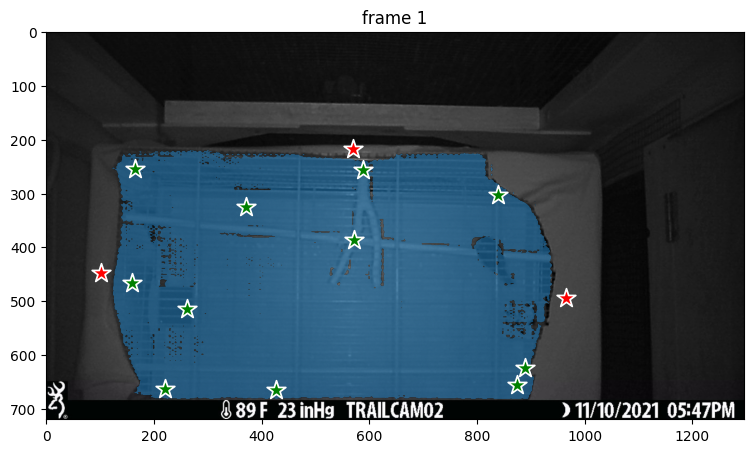

In [284]:
guess_prompts = {
    "I33": {
        "points": np.array(
            [
                [164, 254], [588, 257], [839, 302], [874, 655], [221, 663], [159, 467], [261, 515], [572, 387], [371, 325], [570, 217], [102, 448], [965, 495],
                [890, 625], [427, 666]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,1,1,1,1,1,0,0,0,1,1], np.int32)
    },
}

camera_id = "I33"
video_id = "IMG_0194"
ann_frame_idx = 1

# Interactive annotation
video_path = SEGMENTATION_CONFIG_PATH  / "frames"
files = list((video_path / camera_id / video_id).iterdir())
annotate_and_copy(files[ann_frame_idx])

get_camera_sam_config(
    model_checkpoint_path=MODEL_CHECKPOINT_PATH,
    video_base_path=SEGMENTATION_CONFIG_PATH  / "frames",
    camera_id=camera_id,
    video_id=video_id,
    guess_prompts=guess_prompts,
    ann_frame_idx=ann_frame_idx,
    winner=False,
    output_config_path=None,
    return_video_segments=True,
    output_segment_path=SEGMENTATION_CONFIG_PATH / "labels" / camera_id / f"{video_id}_{ann_frame_idx}.json"
)

## I35,L15

Copied to clipboard: []


frame loading (JPEG): 100%|██████████| 2/2 [00:00<00:00, 45.95it/s]
/Users/sdougherty/Documents/code/sam2/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/Users/sdougherty/Documents/code/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


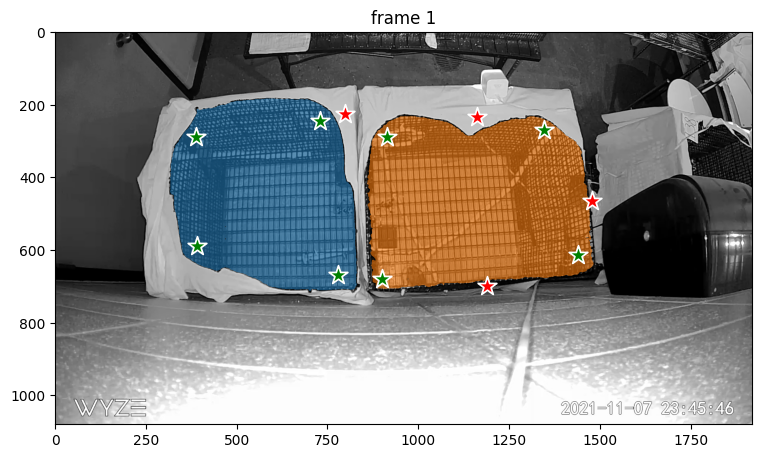

In [314]:
guess_prompts = {
    "I35": {
        "points": np.array(
            [
                [387, 288], [730, 245], [780, 669], [390, 588], [797, 225]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,0], np.int32)
    },
    "L15": {
        "points": np.array(
            [
                [901, 680], [915, 288], [1346, 270], [1440, 614], [1162, 233], [1479, 464], [1189, 699]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,0,0,0], np.int32)
    },
}

camera_id = "I35,L15"
video_id = "45"
ann_frame_idx = 1

# Interactive annotation
video_path = SEGMENTATION_CONFIG_PATH  / "frames"
files = list((video_path / camera_id / video_id).iterdir())
annotate_and_copy(files[ann_frame_idx])

get_camera_sam_config(
    model_checkpoint_path=MODEL_CHECKPOINT_PATH,
    video_base_path=SEGMENTATION_CONFIG_PATH  / "frames",
    camera_id=camera_id,
    video_id=video_id,
    guess_prompts=guess_prompts,
    ann_frame_idx=ann_frame_idx,
    winner=False,
    output_config_path=None,
    return_video_segments=True,
    output_segment_path=SEGMENTATION_CONFIG_PATH / "labels" / camera_id / f"{video_id}_{ann_frame_idx}.json"
)

## I36,I21,L23

Copied to clipboard: []


frame loading (JPEG): 100%|██████████| 2/2 [00:00<00:00, 50.28it/s]
/Users/sdougherty/Documents/code/sam2/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/Users/sdougherty/Documents/code/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


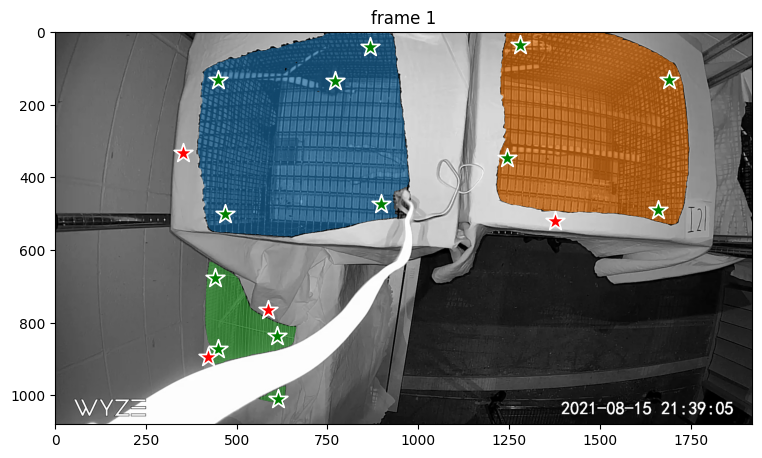

In [345]:
guess_prompts = {
    "I36": {
        "points": np.array(
            [
                [448, 131], [771, 135], [868, 41], [898, 474], [469, 502], [353, 332]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,1,0], np.int32)
    },
    "I21": {
        "points": np.array(
            [
                [1281, 36], [1245, 346], [1661, 489], [1690, 133], [1375, 519]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,0], np.int32)
    },
    "L23": {
        "points": np.array(
            [
                [439, 677], [610, 837], [448, 871], [615, 1011], [420, 894], [587, 766]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,0,0], np.int32)
    },
}

camera_id = "I36,I21,L23"
video_id = "LocalRecord7C78B272481C_album_local_cache 2"
ann_frame_idx = 1

# Interactive annotation
video_path = SEGMENTATION_CONFIG_PATH  / "frames"
files = list((video_path / camera_id / video_id).iterdir())
annotate_and_copy(files[ann_frame_idx])

get_camera_sam_config(
    model_checkpoint_path=MODEL_CHECKPOINT_PATH,
    video_base_path=SEGMENTATION_CONFIG_PATH  / "frames",
    camera_id=camera_id,
    video_id=video_id,
    guess_prompts=guess_prompts,
    ann_frame_idx=ann_frame_idx,
    winner=False,
    output_config_path=None,
    return_video_segments=True,
    output_segment_path=SEGMENTATION_CONFIG_PATH / "labels" / camera_id / f"{video_id}_{ann_frame_idx}.json"
)

## I40,I28,L22,H7

Copied to clipboard: []


frame loading (JPEG): 100%|██████████| 2/2 [00:00<00:00, 39.88it/s]
/Users/sdougherty/Documents/code/sam2/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/Users/sdougherty/Documents/code/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


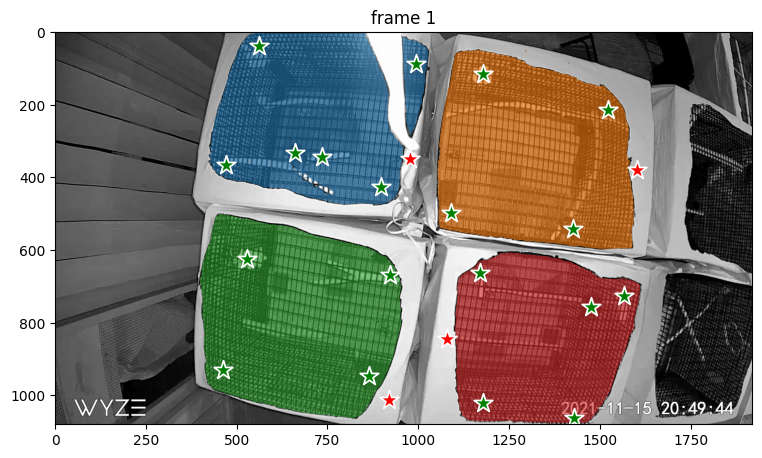

In [378]:
guess_prompts = {
    "I40": {
        "points": np.array(
            [
                [562, 38], [994, 88], [897, 427], [470, 365], [735, 344], [976, 348], [661, 333]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,1,0,1], np.int32)
    },
    "I28": {
        "points": np.array(
            [
                [1177, 116], [1521, 215], [1426, 541], [1090, 497], [1602, 380]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,0], np.int32)
    },
    "L22": {
        "points": np.array(
            [
                [528, 625], [923, 668], [863, 947], [463, 931], [918, 1013]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,0], np.int32)
    },
    "H7": {
        "points": np.array(
            [
                [1169, 662], [1565, 726], [1476, 756], [1178, 1022], [1429, 1063], [1079, 845]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,1,0], np.int32)
    },
}

camera_id = "I40,I28,L22,H7"
video_id = "49"
ann_frame_idx = 1

# Interactive annotation
video_path = SEGMENTATION_CONFIG_PATH  / "frames"
files = list((video_path / camera_id / video_id).iterdir())
annotate_and_copy(files[ann_frame_idx])

get_camera_sam_config(
    model_checkpoint_path=MODEL_CHECKPOINT_PATH,
    video_base_path=SEGMENTATION_CONFIG_PATH  / "frames",
    camera_id=camera_id,
    video_id=video_id,
    guess_prompts=guess_prompts,
    ann_frame_idx=ann_frame_idx,
    winner=False,
    output_config_path=None,
    return_video_segments=True,
    output_segment_path=SEGMENTATION_CONFIG_PATH / "labels" / camera_id / f"{video_id}_{ann_frame_idx}.json"
)

## L13,L26,H10

Copied to clipboard: []


frame loading (JPEG): 100%|██████████| 2/2 [00:00<00:00, 39.50it/s]
/Users/sdougherty/Documents/code/sam2/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/Users/sdougherty/Documents/code/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


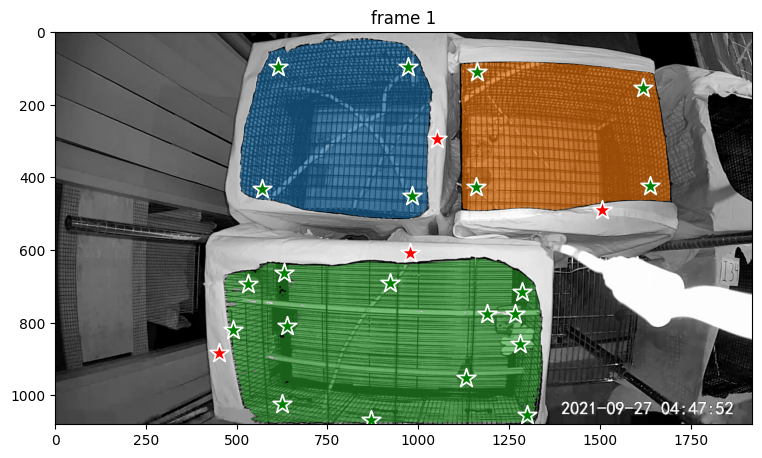

In [405]:
guess_prompts = {
    "L13": {
        "points": np.array(
            [
                [613, 95], [971, 97], [984, 451], [571, 433], [1052, 293]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,0], np.int32)
    },
    "L26": {
        "points": np.array(
            [
                [1161, 111], [1618, 153], [1637, 424], [1158, 427], [1507, 491]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,0], np.int32)
    },
    "H10": {
        "points": np.array(
            [
                [530, 694], [1286, 715], [1132, 953], [1281, 858], [624, 1025], [638, 809], [923, 691], [977, 609], [450, 883],
                [1267, 775], [870, 1069], [1190, 775], [630, 662], [491, 820], [1299, 1055]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,1,1,1,0,0,1,1,1,1,1,1], np.int32)
    },
}

camera_id = "L13,L26,H10"
video_id = "47"
ann_frame_idx = 1

# Interactive annotation
video_path = SEGMENTATION_CONFIG_PATH  / "frames"
files = list((video_path / camera_id / video_id).iterdir())
annotate_and_copy(files[ann_frame_idx])

get_camera_sam_config(
    model_checkpoint_path=MODEL_CHECKPOINT_PATH,
    video_base_path=SEGMENTATION_CONFIG_PATH  / "frames",
    camera_id=camera_id,
    video_id=video_id,
    guess_prompts=guess_prompts,
    ann_frame_idx=ann_frame_idx,
    winner=False,
    output_config_path=None,
    return_video_segments=True,
    output_segment_path=SEGMENTATION_CONFIG_PATH / "labels" / camera_id / f"{video_id}_{ann_frame_idx}.json"
)

## L17

Copied to clipboard: []


frame loading (JPEG): 100%|██████████| 2/2 [00:00<00:00, 54.56it/s]
/Users/sdougherty/Documents/code/sam2/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/Users/sdougherty/Documents/code/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


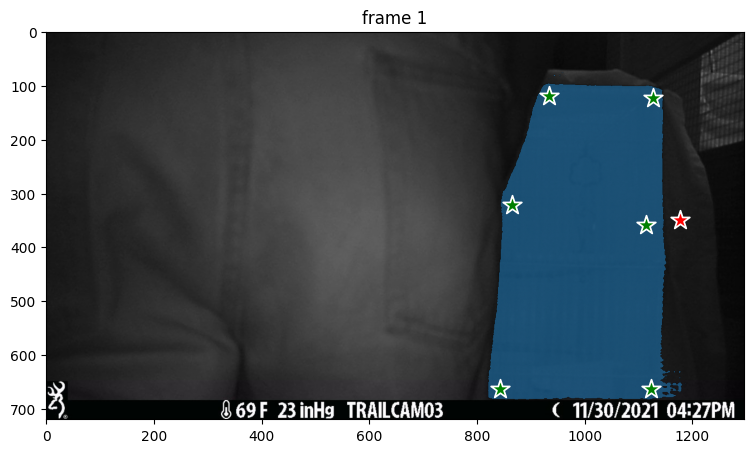

In [ ]:
guess_prompts = {
    "L17": {
        "points": np.array(
            [
                [934, 119], [1128, 123], [1124, 663], [843, 663], [866, 321], [1114, 358], [1177, 349]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,1,1,0], np.int32)
    },
}

camera_id = "L17"
video_id = "IMG_0137" # butt in frame, not using either
ann_frame_idx = 1

# Interactive annotation
video_path = SEGMENTATION_CONFIG_PATH  / "frames"
files = list((video_path / camera_id / video_id).iterdir())
annotate_and_copy(files[ann_frame_idx])

get_camera_sam_config(
    model_checkpoint_path=MODEL_CHECKPOINT_PATH,
    video_base_path=SEGMENTATION_CONFIG_PATH  / "frames",
    camera_id=camera_id,
    video_id=video_id,
    guess_prompts=guess_prompts,
    ann_frame_idx=ann_frame_idx,
    winner=False,
    output_config_path=None,
    return_video_segments=True,
    output_segment_path=SEGMENTATION_CONFIG_PATH / "labels" / camera_id / f"{video_id}_{ann_frame_idx}.json"
)

## L19,L20

Copied to clipboard: []


frame loading (JPEG): 100%|██████████| 2/2 [00:00<00:00, 46.97it/s]
/Users/sdougherty/Documents/code/sam2/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/Users/sdougherty/Documents/code/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


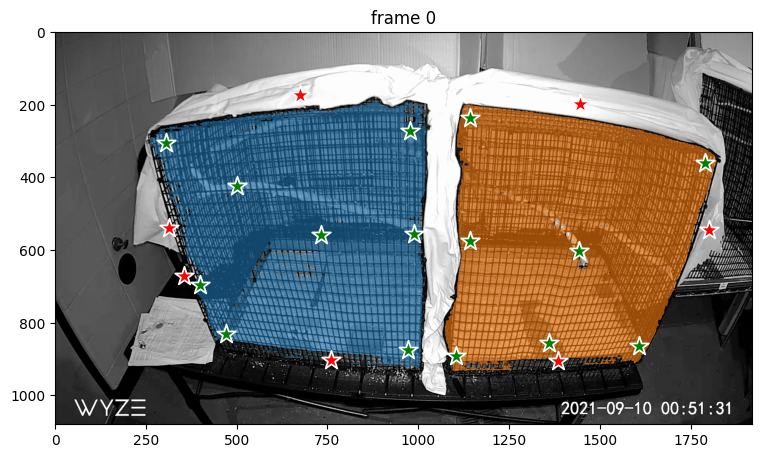

In [469]:
guess_prompts = {
    "L19": {
        "points": np.array(
            [
                [306, 304], [976, 271], [987, 556], [972, 874], [472, 830], [399, 697], [501, 424], [732, 558], [674, 172], [315, 540], [355, 672], [760, 903]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,1,1,1,1,0,0,0,0], np.int32)
    },
    "L20": {
        "points": np.array(
            [
                [1142, 236], [1789, 361], [1607, 864], [1103, 891], [1143, 575], [1443, 603], [1360, 856], [1444, 197], [1800, 546], [1384, 905]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,1,1,1,0,0,0], np.int32)
    },
}

camera_id = "L19,L20"
video_id = "51"
ann_frame_idx = 0

# Interactive annotation
video_path = SEGMENTATION_CONFIG_PATH  / "frames"
files = list((video_path / camera_id / video_id).iterdir())
annotate_and_copy(files[ann_frame_idx])

get_camera_sam_config(
    model_checkpoint_path=MODEL_CHECKPOINT_PATH,
    video_base_path=SEGMENTATION_CONFIG_PATH  / "frames",
    camera_id=camera_id,
    video_id=video_id,
    guess_prompts=guess_prompts,
    ann_frame_idx=ann_frame_idx,
    winner=False,
    output_config_path=None,
    return_video_segments=True,
    output_segment_path=SEGMENTATION_CONFIG_PATH / "labels" / camera_id / f"{video_id}_{ann_frame_idx}.json"
)

## L25

Copied to clipboard: []


frame loading (JPEG): 100%|██████████| 2/2 [00:00<00:00, 55.00it/s]
/Users/sdougherty/Documents/code/sam2/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/Users/sdougherty/Documents/code/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


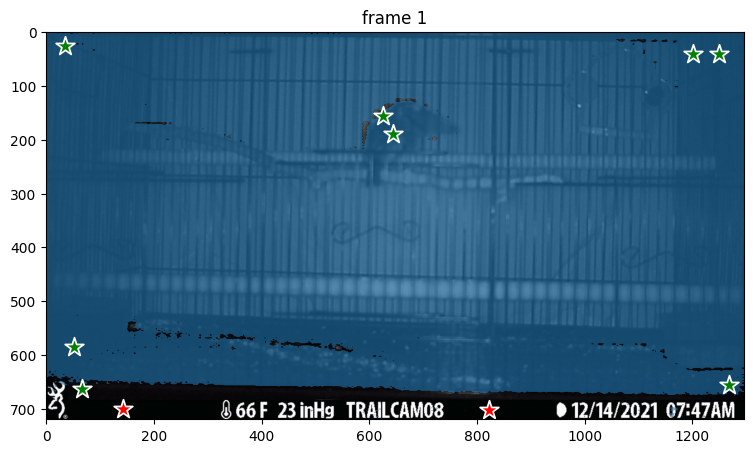

In [486]:
guess_prompts = {
    "L25": {
        "points": np.array(
            [
                [34, 25], [1250, 41], [1269, 656], [67, 663], [143, 700], [823, 702],
                [644, 190], [52, 585], [626, 156], [1202, 41]
            ], dtype=np.float32
        ),
        "labels": np.array([1,1,1,1,0,0,1,1,1,1], np.int32)
    },
}

camera_id = "L25"
video_id = "IMG_0066"
ann_frame_idx = 1

# Interactive annotation
video_path = SEGMENTATION_CONFIG_PATH  / "frames"
files = list((video_path / camera_id / video_id).iterdir())
annotate_and_copy(files[ann_frame_idx])

get_camera_sam_config(
    model_checkpoint_path=MODEL_CHECKPOINT_PATH,
    video_base_path=SEGMENTATION_CONFIG_PATH  / "frames",
    camera_id=camera_id,
    video_id=video_id,
    guess_prompts=guess_prompts,
    ann_frame_idx=ann_frame_idx,
    winner=False,
    output_config_path=None,
    return_video_segments=True,
    output_segment_path=SEGMENTATION_CONFIG_PATH / "labels" / camera_id / f"{video_id}_{ann_frame_idx}.json"
)